# Project 1
## s224360

## Part1: A discrete-time model
### task 1.1

In [1]:
import numpy as np

# P is pi,j from state i to state j
# death is the last row

# 0: state is surgery
# 1: local occurence only
# 2: distant matatasis 
# 3: local and distant occurence
# 4: death 

P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],
              [0 ,     0.986, 0.005, 0.004, 0.005],
              [0,     0, 0.992, 0.003, 0.005],
              [0, 0,0 , 0.991, 0.009],
              [0,0,0,0,1]])
P



array([[0.9915, 0.005 , 0.0025, 0.    , 0.001 ],
       [0.    , 0.986 , 0.005 , 0.004 , 0.005 ],
       [0.    , 0.    , 0.992 , 0.003 , 0.005 ],
       [0.    , 0.    , 0.    , 0.991 , 0.009 ],
       [0.    , 0.    , 0.    , 0.    , 1.    ]])

In [23]:
def sample_conditional_next_state(i, P):
    possible_j = np.arange(i,5,1)
    probs = P[i,i:]
    return np.random.choice(possible_j, p=probs)

sample_conditional_next_state(1, P)

np.int64(1)

In [168]:
import math
np.random.seed(42)
def sample_conditional_next_state(i, P):
    possible_j = np.arange(i,5,1)
    probs = P[i,i:]
    return np.random.choice(possible_j, p=probs)


def cancer_sampler(P, N_women, start=0, check_1000_valid=False):

    life_times = []

    local_occuring_cancer = 0
    state_at_120_all = []
    women_survive_with_cancer12 = 0
    women_survive_with_cancer12_life_expectancy =[]

    for w in range (N_women):

        current_state = start
        lifetime_w = 0
        local_occuring_cancer_w = 0
        state_at_120 = 4

        reoccuring_cancer = False
        while current_state<4:
            
            current_state = sample_conditional_next_state(current_state, P)
            lifetime_w +=1
            if current_state==1 or current_state==3:
                local_occuring_cancer_w = 1
            
            if lifetime_w==120:
                state_at_120 = current_state
            if lifetime_w<=12:
                if current_state in [1,2,3]:
                    reoccuring_cancer = True
        
        if lifetime_w>=12 and reoccuring_cancer:
            women_survive_with_cancer12 +=1
            women_survive_with_cancer12_life_expectancy.append(lifetime_w)

        
        state_at_120_all.append(int(state_at_120))
        local_occuring_cancer += local_occuring_cancer_w
        life_times.append(lifetime_w)

        if women_survive_with_cancer12>=1000 and check_1000_valid:
            life_times = np.array(life_times)
            return life_times, local_occuring_cancer, state_at_120_all,women_survive_with_cancer12, women_survive_with_cancer12_life_expectancy


    life_times = np.array(life_times)

    return life_times, local_occuring_cancer, state_at_120_all,women_survive_with_cancer12, women_survive_with_cancer12_life_expectancy


life_times,local_occuring_cancer,state_at_120_all,women_survive_with_cancer12,women_survive_with_cancer12_life_expectancy = cancer_sampler(P, 1000, start=0)



Amount of women with reoccuring cancer is 71.2 %


Text(0.5, 0, 'Months')

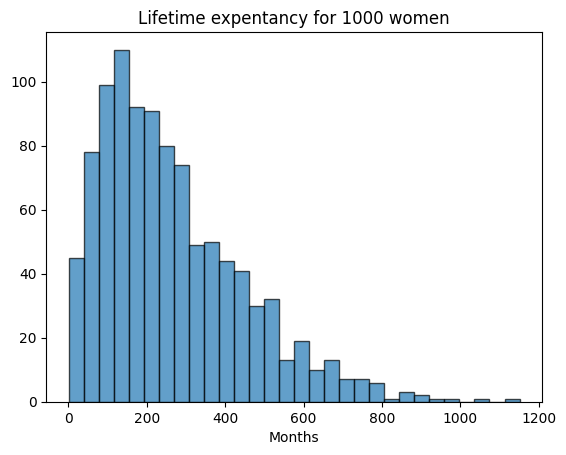

In [30]:
import matplotlib.pyplot as plt
print(f"Amount of women with reoccuring cancer is {np.round(local_occuring_cancer/1000*100,2)} %")
plt.hist(life_times, bins=30, edgecolor= 'black', alpha=0.7)
plt.title('Lifetime expentancy for 1000 women')
plt.xlabel('Months')

### Task 1.2

In [57]:
# pt is the probability distribution over the states at time t
# pt = p0(P^t)

p0 = P[0,:]
p120 = p0 @  (np.linalg.matrix_power(P,120))
print(f"Theoretical prob. of state at t=120 {p120}")

Theoretical prob of state at t=120 [0.35597454 0.15852579 0.16645055 0.06826591 0.25078322]


In [58]:
# our simulations:
values, counts = np.unique_counts(state_at_120_all)
simulated_120_prob = counts /len(state_at_120_all)
print(f"Simulated prob. of state at t=120 {simulated_120_prob}")

Simulated prob. of state at t=120 [0.364 0.165 0.167 0.069 0.235]


In [68]:
from scipy.stats import chisquare
stat, p_value = chisquare(f_obs=counts, f_exp = p120*1000)
print(f" Chi-statistical statistic: {np.round(stat,4)}")
print(f'p-value: {np.round(p_value,4)}')

 Chi-statistical statistic: 1.4484
p-value: 0.8357


### task 1.3

In [124]:
pi_ = np.array([1,0,0,0])
Ps = P[:4,:4]
ps = P[:4,4]

def probability_mass_function(t):
    return pi_@(np.linalg.matrix_power(Ps,t))@ps

def probability_mean():
    inv_PsI = np.linalg.inv(np.eye(4)-Ps)
    return pi_@(inv_PsI)@np.ones((4))



probability_mean(), probability_mass_function(5)

(np.float64(262.3716153127931), np.float64(0.0011417710566044876))

Amount of women with reoccuring cancer is 71.2 %


Text(0.5, 0, 'Months')

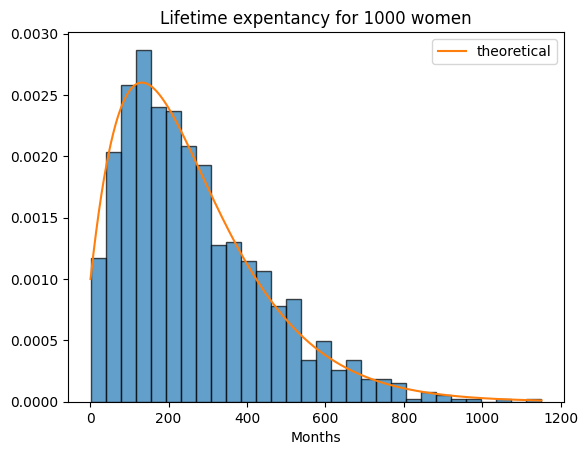

In [144]:
theo_dist = []
for t in range(0,max(life_times)):
    theo_dist.append(probability_mass_function(t))


theo_dist = np.array(theo_dist)
import matplotlib.pyplot as plt
print(f"Amount of women with reoccuring cancer is {np.round(local_occuring_cancer/1000*100,2)} %")
plt.hist(life_times, bins=30, edgecolor= 'black', alpha=0.7, density=True)
plt.plot(list(range(1,max(life_times)+1)),theo_dist , label='theoretical')
plt.title('Lifetime expentancy for 1000 women')
plt.legend()
plt.xlabel('Months')

In [145]:
# statistical test:

bins = 15

# sim values 
hist_sim, bin_edges = np.histogram(life_times, bins=bins)

t_values = np.arange( 0,max(life_times))

hist_theo = []
for i in range(bins):
    left = bin_edges[i]
    right = bin_edges[i+1]

    if i == bins-1:
        mask = (t_values >= left) & (t_values <= right)
    else:
        mask = (t_values >= left) & (t_values < right)

    hist_theo.append(1000 * np.sum(theo_dist[mask]))

hist_theo = np.array(hist_theo)

# scipy requires observed and expected to sum exactly the same
hist_theo *= np.sum(hist_sim) / np.sum(hist_theo)

stat, p_value = chisquare(f_obs=hist_sim, f_exp=hist_theo)
print(f"Chi-square statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

Chi-square statistic: 8.5976
p-value: 0.8559


### Task 4 

In [169]:
#Estimate the expected lifetime, after surgery, of a woman who survives the
#first 12 months following surgery, but whose breast cancer has also reap-
#peared within the first 12 months, either locally or distant
np.random.seed(42)
life_times,local_occuring_cancer,state_at_120_all,women_survive_with_cancer12,women_survive_with_cancer12_life_expectancy = cancer_sampler(P, N_women=20_000, start=0,check_1000_valid=True)
women_survive_with_cancer12_life_expectancy = np.array(women_survive_with_cancer12_life_expectancy)
print(len(women_survive_with_cancer12_life_expectancy))

print(f"Average life expectancy of women who survive the first 12 months but also \n gets reoccuring cancer in 12 months is {np.round(np.mean(women_survive_with_cancer12_life_expectancy),2)} months")

1000
Average life expectancy of women who survive the first 12 months but also 
 gets reoccuring cancer in 12 months is 177.9 months


### task 5

In [171]:
def cancer_sampler_2(P, N_women, start=0):

    life_times = []

    women_survive_350_months = 0


    for w in range (N_women):

        current_state = start
        lifetime_w = 0

        while current_state<4:
            
            current_state = sample_conditional_next_state(current_state, P)
            lifetime_w +=1
            
        if lifetime_w<=350 :
            women_survive_350_months +=1

        life_times.append(lifetime_w)

    life_times = np.array(life_times)

    return life_times, women_survive_350_months

In [178]:
survive_350_list = []
lifetimes_list = []
means_list = []

np.random.seed(42)
for rep in range (100):
    life_times, women_survive_350_months = cancer_sampler_2(P, 200, start=0)
    survive_350_list.append(women_survive_350_months)
    lifetimes_list.append(life_times)
    means_list.append(women_survive_350_months/(200))


lifetimes_list = np.array(lifetimes_list)

In [189]:
# crude MC estimator: fraction dying within 350 months
Y = np.array(means_list)

# control variate: mean lifetime in each repetition
X = np.mean(lifetimes_list, axis=1)

# known theoretical mean lifetime
EX = probability_mean()

# estimate optimal beta
beta_hat = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)

# control variate estimator
Y_cv = Y - beta_hat * (X - EX)

print("Crude MC estimate:", np.round(np.mean(Y),4))
print("Control variate estimate:", np.round(np.mean(Y_cv),4))

print("Crude variance:", np.round((np.var(Y, ddof=1)),4))
print("Control variate variance:", np.round(np.var(Y_cv, ddof=1),4))

variance_reduction = np.var(Y, ddof=1) / np.var(Y_cv, ddof=1)
print("Variance reduction factor:", np.round(variance_reduction,4))

Crude MC estimate: 0.7375
Control variate estimate: 0.7371
Crude variance: 0.0013
Control variate variance: 0.0003
Variance reduction factor: 4.2098


### task 6 in report

# Part 2 A continous-time model
### part 7

In [190]:
# transition rate matric Q 

Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001],
              [0, -0.014, 0.005, 0.004, 0.005],
              [0,0, -0.008, 0.003, 0.005],
              [0,0,0, -0.009, 0.009],
              [0,0,0,0,0]])

Q

array([[-0.0085,  0.005 ,  0.0025,  0.    ,  0.001 ],
       [ 0.    , -0.014 ,  0.005 ,  0.004 ,  0.005 ],
       [ 0.    ,  0.    , -0.008 ,  0.003 ,  0.005 ],
       [ 0.    ,  0.    ,  0.    , -0.009 ,  0.009 ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ]])

In [214]:
# Simulate 1000 women, all starting in state 1, until death. Summarize the
#lifetime distribution after surgery, for example in a histogram. Report the
#mean, along with a confidence interval, and the standard deviation, also
#with a confidence interval. In what proportion of women has the cancer
#reappeared distantly after 30.5 months?

import math
np.random.seed(42)
def sample_next_state(i, Q):
    pii = -Q[i,i]
    q_j = []
    for j in range(Q.shape[1]):
        if i!= j:
            q_j.append(Q[i,j]/pii)
        if i== j:
            q_j.append(0)
    
    q_j = np.array(q_j)
    return int(np.random.choice(np.arange(0,5), p=q_j))

def sample_next_passing_time(i, Q):
    pii = -Q[i,i]

    return np.random.exponential( scale=1/pii)


def cancer_sampler_continous(Q, N_women, start=0):

    life_times = []
    distant_occuring_cancer = 0

    for w in range (N_women):

        current_state = start
        lifetime_w = 0
        distant_w = False

        while current_state<4:
            
            passing_time = sample_next_passing_time(current_state, Q)
            lifetime_w +=passing_time

            current_state = sample_next_state(current_state, Q)

            if (current_state ==2 or current_state==3) and lifetime_w>30.5  :
                distant_w = True
            
        if distant_w:
            distant_occuring_cancer +=1
        life_times.append(lifetime_w)

    life_times = np.array(life_times)

    return life_times, distant_occuring_cancer


life_times,distant_occuring_cancer  = cancer_sampler_continous(Q, 1000, start=0)




Amount of women with reoccuring cancer is 59.9 %


Text(0.5, 0, 'Months')

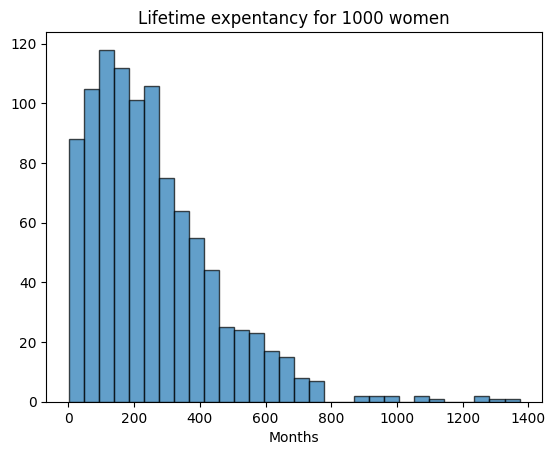

In [215]:
import matplotlib.pyplot as plt
print(f"Amount of women with reoccuring cancer is {np.round(distant_occuring_cancer/1000*100,2)} %")
plt.hist(life_times, bins=30, edgecolor= 'black', alpha=0.7)
plt.title('Lifetime expentancy for 1000 women')
plt.xlabel('Months')

### part 8 

In [226]:
np.mean(life_times)

np.float64(256.3715684046518)

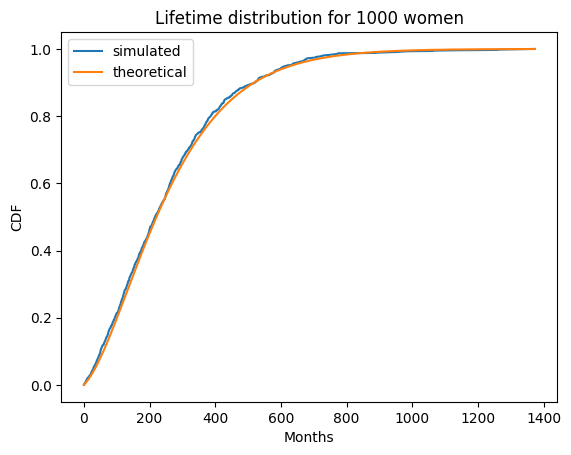

In [237]:
import scipy
def FT (Q,t):
    p0 = np.array([1,0,0,0])
    Qs = Q[:4, :4]
    
    return float(1-p0@( scipy.linalg.expm(Qs*t) ) @np.ones(4))


# empirical/simulated CDF
sorted_life_times = np.sort(life_times)
sim_cdf = np.arange(1, len(sorted_life_times)+1) / len(sorted_life_times)

# theoretical CDF
t_grid = np.linspace(0, max(life_times), 500)
theo_cdf = np.array([FT(Q, t) for t in t_grid])

plt.figure()

plt.plot(sorted_life_times, sim_cdf, label='simulated')
plt.plot(t_grid, theo_cdf, label='theoretical')
plt.title('Lifetime distribution for 1000 women')
plt.legend()
plt.xlabel('Months')
plt.ylabel('CDF')
plt.show()

In [244]:
# statistical test (Ks for continous):
# made FT function into np.array
def FT_vec(x):
    x = np.asarray(x)
    return np.array([FT(Q, t) for t in x])

res = scipy.stats.kstest(life_times, FT_vec)

print(f"KS statistic = {np.round(res.statistic,4)}")
print(f"p-value = {np.round(res.pvalue,4)}")


KS statistic = 0.0239
p-value = 0.611


### part 9

In [245]:
Q = np.array([[0, 0.0025, 0.00125, 0, 0.001],
              [0,0,0, 0.002, 0.005],
              [0,0,0, 0.003, 0.005],
              [0,0,0,0,0.009],
              [0,0,0,0,0]])

Q

array([[0.     , 0.0025 , 0.00125, 0.     , 0.001  ],
       [0.     , 0.     , 0.     , 0.002  , 0.005  ],
       [0.     , 0.     , 0.     , 0.003  , 0.005  ],
       [0.     , 0.     , 0.     , 0.     , 0.009  ],
       [0.     , 0.     , 0.     , 0.     , 0.     ]])

In [246]:
life_times

array([5.52080106e+01, 1.82763119e+02, 1.10727226e+02, 2.69846611e+02,
       2.44980541e+02, 2.14702097e+02, 5.70039147e+02, 1.78115791e+01,
       8.19236494e+01, 3.42571376e+02, 3.30011108e+02, 1.07182872e+02,
       2.71784768e+02, 4.96502018e+01, 9.11480810e+00, 1.74452445e+02,
       3.78087448e+02, 3.25559600e+02, 4.26649228e+02, 1.93784082e+02,
       2.29093886e+02, 5.09314923e+01, 3.17883313e+02, 3.86872666e+02,
       5.69422414e+02, 1.93805681e+02, 2.52819182e+02, 3.73496324e+02,
       1.42550084e+02, 5.81642656e+02, 1.96417058e+02, 5.78952398e+02,
       8.92368996e+01, 1.24857794e+02, 1.74241951e+02, 3.05212575e+02,
       6.77815305e+02, 2.47532847e+02, 9.57191927e+01, 4.66970533e+02,
       4.04605914e+02, 1.17347806e+02, 5.74325530e+01, 2.62332328e+02,
       2.57361816e+02, 4.85121534e+02, 4.59867005e+02, 1.16710162e+02,
       4.65478400e+02, 2.90937358e+02, 6.57574444e+01, 4.33448241e+02,
       5.43050379e+02, 1.67488099e+02, 1.67655980e+02, 3.80318610e+02,
      

In [ ]:
# survival function is defined as the proportion of women alive at time t
# St = P(T>t) 
St 